# **🧱 Feature Engineering**

Construcción de variables nuevas a partir de los hallazgos de la exploración y del baseline. Cada feature se evalúa por su **relación con la variable objetivo**:

1. **Tasa de fraude por tramo o categoría**, comparada con la tasa global, igual que en la exploración.
2. **Ranking univariado** de todas las variables (originales y nuevas), para ver si las nuevas aportan más señal que las existentes.
3. **Redundancia** con las variables originales: una feature que repite información ya disponible no suma al modelo.

`j` requiere un cuidado especial: con 8.324 categorías, la tasa de fraude por categoría calculada sobre todo el dataset exagera su señal, así que se calcula **out-of-fold**. Las features que no muestran señal se mantienen en el notebook como parte del registro del análisis.

## **📚 Librerías**

In [1]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Métricas y folds, los mismos del baseline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Librerías de visualización
import plotly.express as px
import plotly.io as pio

In [2]:
# Gráficos interactivos en el editor y PNG estático para GitHub y el informe
pio.renderers.default = 'plotly_mimetype+png'
pio.templates.default = 'plotly_white'

COLOR_PRINCIPAL = '#2a78d6'
COLORES_ORIGEN = {'Original': '#898781', 'Nueva': '#eb6834', 'Aleatoria': '#2a78d6'}

# Parámetros del análisis
SEMILLA = 42
NUMERO_FOLDS = 5
NUMERO_TRAMOS = 10
SUAVIZADO = 20
MINIMO_TRANSACCIONES_PAIS = 100
MAXIMO_VALORES_DISCRETOS = 30

In [3]:
# Funciones para evaluar cada feature contra la variable objetivo


def graficar_tasa_fraude(fraude, agrupacion, titulo):
    """Gráfico de barras con la tasa de fraude por valor de la agrupación y la tasa global como referencia."""
    tasa_por_valor = fraude.groupby(agrupacion, observed=True).mean().mul(100).round(2)
    fig = px.bar(
        x=tasa_por_valor.index.astype(str),
        y=tasa_por_valor.to_numpy(),
        text_auto=True,
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={'x': agrupacion.name, 'y': '% de fraude'},
        title=titulo,
    )
    fig.update_traces(textposition='outside')
    fig.update_xaxes(type='category')
    fig.add_hline(y=fraude.mean() * 100, line_dash='dash', annotation_text='Tasa global', annotation_position='right')
    fig.update_layout(height=350)
    return fig


def tasa_fraude_oof(categorias, fraude, folds):
    """Tasa de fraude suavizada por categoría; cada fila recibe la calculada con los folds que no la contienen."""
    resultado = pd.Series(np.nan, index=categorias.index)
    for indices_train, indices_validacion in folds:
        fraude_train = fraude.iloc[indices_train]
        tasa_train = fraude_train.mean()
        estadisticas = fraude_train.groupby(categorias.iloc[indices_train], observed=True).agg(['sum', 'count'])
        tasa_suavizada = (estadisticas['sum'] + SUAVIZADO * tasa_train) / (estadisticas['count'] + SUAVIZADO)
        resultado.iloc[indices_validacion] = (
            categorias.iloc[indices_validacion].map(tasa_suavizada).astype(float).fillna(tasa_train).to_numpy()
        )
    return resultado

## **🔢 Datos**

In [4]:
# Carga del dataset crudo con la fecha como datetime
df = pd.read_csv('../data/raw/dataset.csv', parse_dates=['fecha'])
columnas_originales = df.columns.drop(['fecha', 'fraude']).tolist()

In [5]:
# Mismos folds estratificados del baseline, para calcular las tasas out-of-fold
folds = list(
    StratifiedKFold(n_splits=NUMERO_FOLDS, shuffle=True, random_state=SEMILLA).split(df, df['fraude'])
)

## **🕐 Variables temporales**

En el baseline `fecha` quedó fuera del modelo. Como se mostró que las transacciones se comportan como independientes del tiempo, la fecha en sí no aporta, pero sí pueden hacerlo patrones que se repiten: la **hora del día** y el **día de la semana**.

In [6]:
# Hora del día (0–23) y día de la semana (0 = lunes, 6 = domingo)
df['hora'] = df['fecha'].dt.hour
df['dia_semana'] = df['fecha'].dt.dayofweek

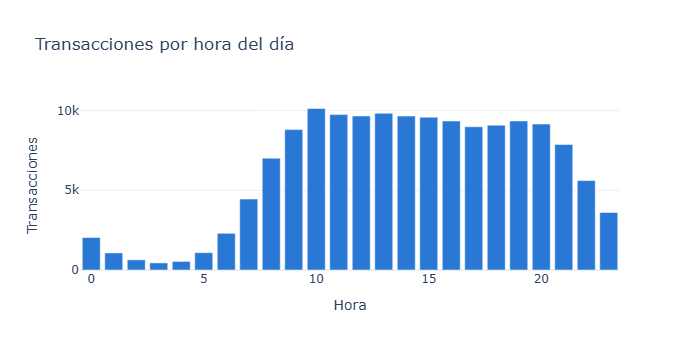

In [7]:
# Volumen de transacciones por hora, para saber qué tan confiable es la tasa de cada una
fig = px.bar(
    df['hora'].value_counts().sort_index(),
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'hora': 'Hora', 'value': 'Transacciones'},
    title='Transacciones por hora del día',
)
fig.update_layout(showlegend=False, height=350)
fig.show()

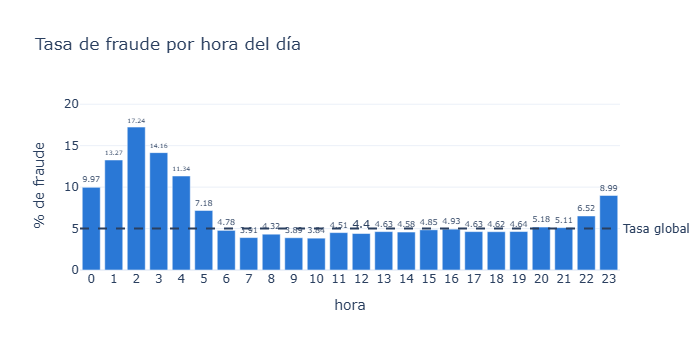

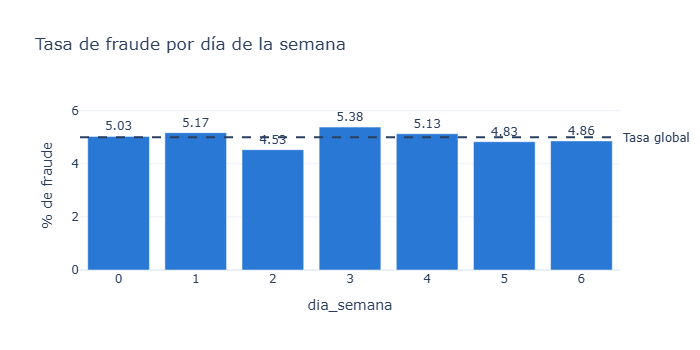

In [8]:
# Tasa de fraude por hora del día y por día de la semana
graficar_tasa_fraude(df['fraude'], df['hora'], 'Tasa de fraude por hora del día').show()
graficar_tasa_fraude(df['fraude'], df['dia_semana'], 'Tasa de fraude por día de la semana').show()

**💡 Hallazgos**

- La **hora del día es muy informativa**: entre las 0 y las 4 la tasa de fraude va de **10% a 17%** (pico a las 2, con 17,2%), 2 a 3,5 veces la tasa global. Entre las 7 y las 21 se mantiene estable en 3,8–5,2%, y sube de nuevo a las 22 (6,5%) y a las 23 (9,0%).
- La madrugada tiene **poco volumen** (entre 450 y 2.000 transacciones por hora, frente a ~9.000–10.000 durante el día), así que concentra una parte chica del total de fraudes, aunque con una tasa mucho mayor.
- El **día de la semana no diferencia**: la tasa va de 4,5% a 5,4%. Además, 45 días cubren solo ~6 semanas, así que cada día de la semana queda confundido con las semanas puntuales en que cayó.
- `hora` queda como candidata. Para un modelo de árboles alcanza con la hora como número: puede separar la madrugada sin necesidad de un encoding cíclico.

## **🔤 Variable `j`**

`j` fue la variable más importante del baseline (~29%), con 8.324 categorías. Cada categoría abarca casi todo el periodo, varios países y montos muy distintos, así que se comporta más como una **categoría de producto o comercio** que como un identificador de usuario. Se construyen cuatro tipos de features a partir de ella:

- **Tamaño**: cuántas transacciones tiene la categoría.
- **Tasa de fraude out-of-fold**: el riesgo histórico de la categoría, sin usar la etiqueta de la propia transacción.
- **Monto relativo**: qué tan inusual es el monto para esa categoría.
- **Actividad reciente**: cuántas transacciones tuvo la categoría en la hora y el día previos, para capturar ataques concentrados.

In [9]:
# Tamaño de cada categoría: transacciones en el dataset
df['j_frecuencia'] = df['j'].map(df['j'].value_counts())

tramos_tamano = pd.cut(
    df['j_frecuencia'], bins=[0, 1, 5, 20, 100, 1000, np.inf], labels=['1', '2–5', '6–20', '21–100', '101–1.000', '>1.000']
).rename('transacciones de la categoría')
df.groupby(tramos_tamano, observed=True).agg(
    categorias=('j', 'nunique'), transacciones=('j', 'size'), tasa_fraude=('fraude', 'mean')
).assign(tasa_fraude=lambda tabla: tabla['tasa_fraude'].mul(100).round(2))

,categorias,transacciones,tasa_fraude
transacciones de la categoría,,,
1,2258,2258,2.79
2–5,2708,8195,3.21
6–20,2005,21438,3.71
21–100,1089,47524,4.82
101–1.000,257,59898,5.58
>1.000,7,10687,7.00


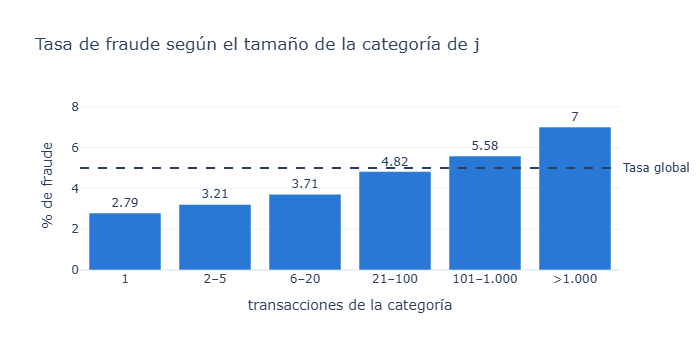

In [10]:
# Tasa de fraude según el tamaño de la categoría
graficar_tasa_fraude(df['fraude'], tramos_tamano, 'Tasa de fraude según el tamaño de la categoría de j').show()

In [11]:
# Tasa de fraude por categoría: calculada sobre todo el dataset (ingenua) vs. out-of-fold.
# La ingenua usa la etiqueta de la propia transacción, así que su AUC sobreestima la señal real
tasa_ingenua = df.groupby('j')['fraude'].transform('mean')
df['j_tasa_fraude'] = tasa_fraude_oof(df['j'], df['fraude'], folds)

print(f"AUC tasa ingenua:      {roc_auc_score(df['fraude'], tasa_ingenua):.3f}")
print(f"AUC tasa out-of-fold:  {roc_auc_score(df['fraude'], df['j_tasa_fraude']):.3f}")

AUC tasa ingenua:      0.783
AUC tasa out-of-fold:  0.645


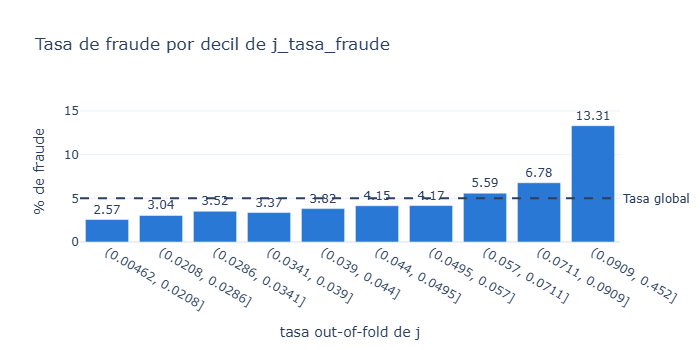

In [12]:
# Tasa de fraude real por decil de la tasa out-of-fold de la categoría
graficar_tasa_fraude(
    df['fraude'],
    pd.qcut(df['j_tasa_fraude'], NUMERO_TRAMOS, duplicates='drop').rename('tasa out-of-fold de j'),
    'Tasa de fraude por decil de j_tasa_fraude',
).show()

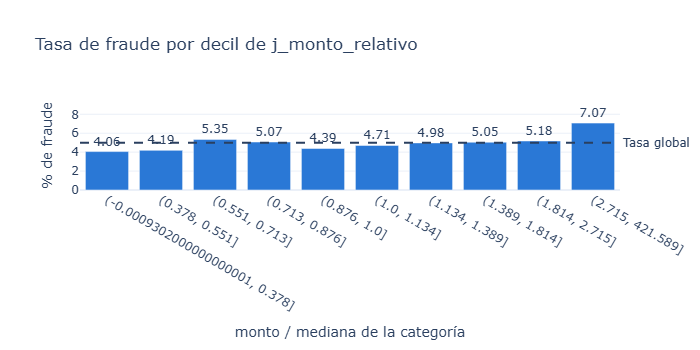

In [13]:
# Monto relativo a la mediana de la categoría: > 1 es más caro de lo habitual para esa categoría
df['j_monto_relativo'] = df['monto'] / df.groupby('j')['monto'].transform('median')

graficar_tasa_fraude(
    df['fraude'],
    pd.qcut(df['j_monto_relativo'], NUMERO_TRAMOS).rename('monto / mediana de la categoría'),
    'Tasa de fraude por decil de j_monto_relativo',
).show()

In [14]:
# Actividad reciente de la categoría: transacciones previas de la misma j en la última hora y en las últimas 24 horas.
# Solo mira hacia atrás, así que se puede calcular en el momento de la decisión
ordenadas = df[['fecha', 'j']].sort_values('fecha')
indice_original = ordenadas.index
ordenadas = ordenadas.set_index('fecha').assign(transaccion=1)

for ventana, nombre in [('1h', 'j_transacciones_1h'), ('24h', 'j_transacciones_24h')]:
    conteo = ordenadas.groupby('j')['transaccion'].transform(lambda transacciones: transacciones.rolling(ventana).sum() - 1)
    df.loc[indice_original, nombre] = conteo.to_numpy()

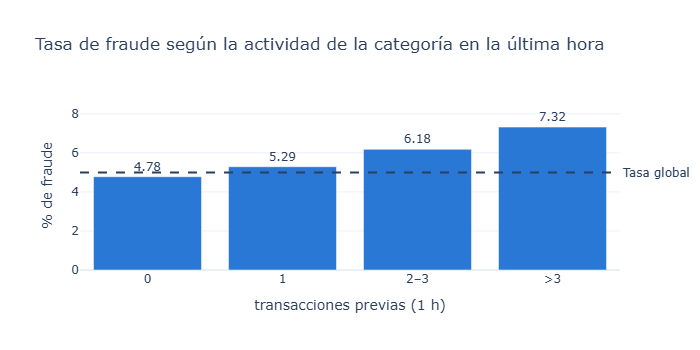

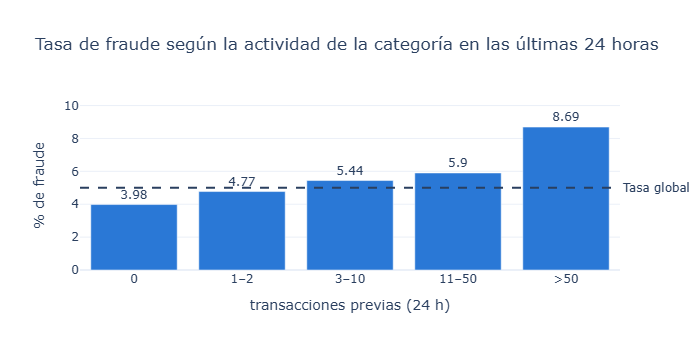

In [15]:
# Tasa de fraude según la actividad reciente de la categoría
graficar_tasa_fraude(
    df['fraude'],
    pd.cut(df['j_transacciones_1h'], bins=[-1, 0, 1, 3, np.inf], labels=['0', '1', '2–3', '>3']).rename('transacciones previas (1 h)'),
    'Tasa de fraude según la actividad de la categoría en la última hora',
).show()
graficar_tasa_fraude(
    df['fraude'],
    pd.cut(df['j_transacciones_24h'], bins=[-1, 0, 2, 10, 50, np.inf], labels=['0', '1–2', '3–10', '11–50', '>50']).rename('transacciones previas (24 h)'),
    'Tasa de fraude según la actividad de la categoría en las últimas 24 horas',
).show()

In [16]:
# Correlación de la actividad reciente con el tamaño de la categoría, para ver si mide algo distinto
df[['j_frecuencia', 'j_transacciones_1h', 'j_transacciones_24h']].corr(method='spearman').round(3)

,j_frecuencia,j_transacciones_1h,j_transacciones_24h
j_frecuencia,1.000,0.546,0.886
j_transacciones_1h,0.546,1.000,0.591
j_transacciones_24h,0.886,0.591,1.000


**💡 Hallazgos**

- **El fraude crece con el tamaño de la categoría**: 2,8% en las que tienen una sola transacción y 7,0% en las 7 categorías con más de 1.000. Además, 2.258 categorías (27%) aparecen una sola vez, así que en cualquier partición van a caer en validación sin haberse visto en train.
- **La tasa por categoría calculada de forma ingenua exagera la señal**: su AUC es de 0,783, contra 0,645 out-of-fold. La diferencia viene de usar la etiqueta de la propia transacción, sobre todo en las categorías chicas. Esto refuerza la sospecha del baseline de que la importancia de `j` (~29%) está inflada por memorización.
- Aun así, **`j` tiene señal real**: en el decil más riesgoso de `j_tasa_fraude` la tasa es de 13,3%, frente a 2,6% en el menos riesgoso.
- `j_monto_relativo` solo diferencia en el decil más alto (montos más de 2,7 veces la mediana de su categoría), con 7,1% de fraude. En el resto de los deciles se mueve entre 4% y 5,3%, parecido a lo que ya muestra `monto`.
- **La actividad reciente de la categoría sube el riesgo**: de 4,8% sin transacciones en la última hora a 7,3% con más de 3, y de 4,0% a 8,7% en la ventana de 24 horas. Pero `j_transacciones_24h` tiene una correlación de 0,89 con `j_frecuencia`: mide sobre todo el tamaño de la categoría, no un ataque concentrado. La ventana de 1 hora está menos correlacionada (0,55), pero afecta a pocas transacciones.

## **🚩 Nulos y valores especiales**

La exploración mostró nulos en pares y valores que parecen códigos más que cantidades: `f` negativos, `d` truncada en 50 y una masa de ceros en `e`. LightGBM maneja los nulos de forma nativa y puede cortar en esos valores, así que se espera poca ganancia, pero los flags hacen explícita esa información. Se suma un flag de **monto entero**, un patrón que a veces aparece en pruebas de tarjetas.

In [17]:
# Flags de nulos y valores especiales
df['bc_nulo'] = df['b'].isna().astype(int)
df['f_negativo'] = (df['f'] < 0).astype(int)
df['d_tope'] = (df['d'] == 50).astype(int)
df['e_cero'] = (df['e'] == 0).astype(int)
df['monto_entero'] = (df['monto'].mul(100).round() % 100 == 0).astype(int)
flags = ['bc_nulo', 'f_negativo', 'd_tope', 'e_cero', 'monto_entero']

In [18]:
# Tasa de fraude con cada flag activo e inactivo, y porcentaje de transacciones con el flag activo
tasa_flags = pd.DataFrame([
    {
        'flag': flag,
        '% transacciones con flag': df[flag].mean() * 100,
        'tasa con flag': df.loc[df[flag] == 1, 'fraude'].mean() * 100,
        'tasa sin flag': df.loc[df[flag] == 0, 'fraude'].mean() * 100,
    }
    for flag in flags
]).set_index('flag').round(2)
tasa_flags

,% transacciones con flag,tasa con flag,tasa sin flag
flag,,,
bc_nulo,8.66,6.38,4.87
f_negativo,0.85,8.77,4.97
d_tope,25.73,2.81,5.76
e_cero,43.37,5.60,4.54
monto_entero,1.34,4.12,5.01


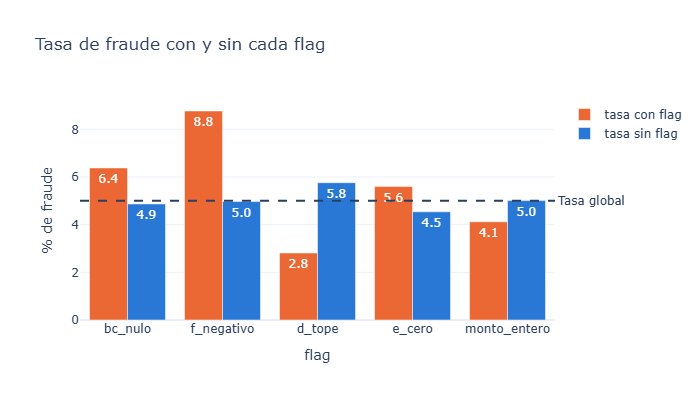

In [19]:
# Comparación visual de la tasa de fraude con y sin cada flag
fig = px.bar(
    tasa_flags[['tasa con flag', 'tasa sin flag']].reset_index().melt(id_vars='flag', var_name='valor', value_name='% de fraude'),
    x='flag',
    y='% de fraude',
    color='valor',
    barmode='group',
    text_auto='.1f',
    color_discrete_map={'tasa con flag': '#eb6834', 'tasa sin flag': COLOR_PRINCIPAL},
    title='Tasa de fraude con y sin cada flag',
)
fig.add_hline(y=df['fraude'].mean() * 100, line_dash='dash', annotation_text='Tasa global', annotation_position='right')
fig.update_layout(height=400, legend_title_text='')
fig.show()

**💡 Hallazgos**

- `d_tope` es el flag más claro: una de cada cuatro transacciones tiene `d = 50`, con **2,8% de fraude frente a 5,8%**. Es consistente con leer `d` como una variable de historial truncada, donde 50 significa "50 o más".
- `f_negativo` duplica la tasa (8,8% frente a 5,0%), pero solo afecta al 0,85% de las transacciones. `bc_nulo` (6,4% frente a 4,9%) y `e_cero` (5,6% frente a 4,5%) diferencian poco.
- **`monto_entero` no muestra señal**: 4,1% de fraude frente a 5,0%. La hipótesis de montos redondos por pruebas de tarjetas no se sostiene en estos datos.
- LightGBM ya ve los nulos y puede cortar en `d = 50` o en `f < 0`, así que estos flags probablemente repiten información que el modelo ya tiene (ver la sección de redundancia).

## **🌎 País agrupado**

In [20]:
# Los países con pocas transacciones tienen tasas inestables: se agrupan en "Otros"
frecuencia_pais = df['g'].value_counts()
paises_frecuentes = frecuencia_pais[frecuencia_pais >= MINIMO_TRANSACCIONES_PAIS].index
df['g_agrupado'] = df['g'].where(df['g'].isin(paises_frecuentes) | df['g'].isna(), 'Otros')

print(f'Países agrupados en "Otros": {(frecuencia_pais < MINIMO_TRANSACCIONES_PAIS).sum()}')
df['g_agrupado'].value_counts(dropna=False)

Países agrupados en "Otros": 45


g_agrupado
BR       111628
AR        31964
UY         2967
US         2273
Otros       380
SE          358
MX          236
NaN         194
Name: count, dtype: int64

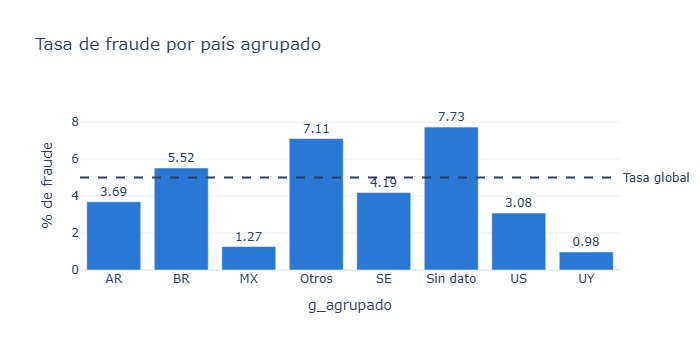

In [21]:
# Tasa de fraude por país agrupado; el nulo se muestra como categoría propia
graficar_tasa_fraude(
    df['fraude'], df['g_agrupado'].fillna('Sin dato'), 'Tasa de fraude por país agrupado'
).show()

**💡 Hallazgos**

- 45 países tienen menos de 100 transacciones y pasan a **"Otros"** (380 transacciones, 7,1% de fraude). Quedan Brasil, Argentina, Uruguay, Estados Unidos, Suecia, México, "Otros" y el nulo.
- Uruguay (1,0%) y México (1,3%) siguen siendo los de menor riesgo, y Estados Unidos (3,1%) también queda por debajo de la media.
- Agrupar no cambia la señal de la variable (ver el ranking), pero evita que el modelo aprenda tasas de países con una o dos transacciones.

## **👤 Ratios de historial**

`f`, `l`, `m`, `d` y `h` eran más bajas en los fraudes, y en la exploración se interpretaron como variables de historial o actividad de la cuenta. Si alguna mide antigüedad y otra actividad, su cociente podría capturar la **intensidad de uso** (por ejemplo, mucha actividad en una cuenta nueva). Sin saber qué mide cada una, se prueban varios cocientes.

In [22]:
# Cocientes entre variables de historial; si el denominador es 0 el cociente queda nulo
ratios = {
    'ratio_f_l': ('f', 'l'),
    'ratio_m_l': ('m', 'l'),
    'ratio_h_l': ('h', 'l'),
    'ratio_d_m': ('d', 'm'),
}
for nombre, (numerador, denominador) in ratios.items():
    df[nombre] = df[numerador] / df[denominador].replace(0, np.nan)

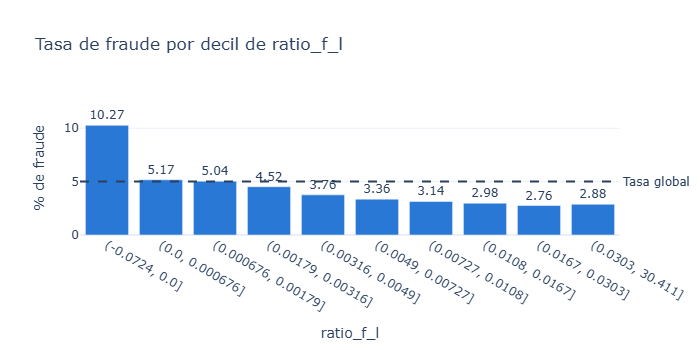

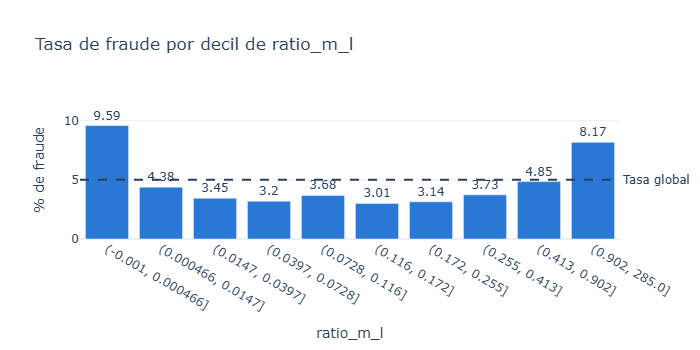

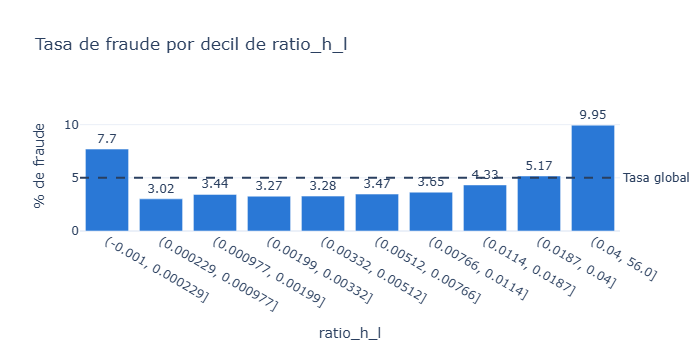

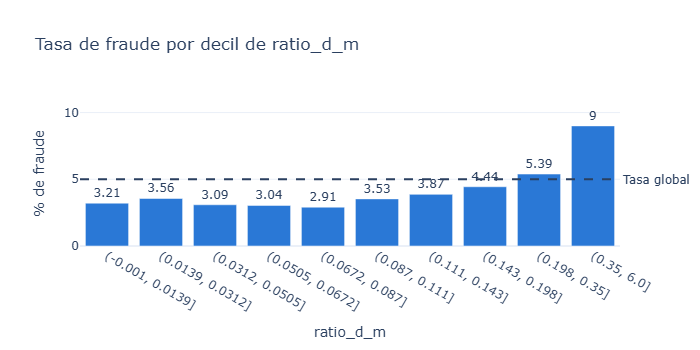

In [23]:
# Tasa de fraude por decil de cada cociente
for nombre in ratios:
    graficar_tasa_fraude(
        df['fraude'], pd.qcut(df[nombre], NUMERO_TRAMOS, duplicates='drop').rename(nombre), f'Tasa de fraude por decil de {nombre}'
    ).show()

**💡 Hallazgos**

- `ratio_f_l` baja de forma monótona, de 10,3% de fraude en el decil más bajo a 2,9% en el más alto, pero tiene una correlación de 0,91 con `f`: es prácticamente `f` expresada de otra forma.
- `ratio_m_l`, `ratio_h_l` y `ratio_d_m` muestran una **forma de U o suben en los extremos**: `ratio_h_l` llega a 10,0% en el decil más alto y `ratio_m_l` a 9,6% en el más bajo y 8,2% en el más alto. Si `l` midiera antigüedad, un `h` alto en relación con `l` sería mucha actividad en una cuenta nueva, un patrón típico de fraude. Pero es una hipótesis, porque las variables están anonimizadas.
- Ningún cociente supera por sí solo a las variables que lo forman: su AUC univariado va de 0,62 a 0,64, contra 0,681 de `f` y 0,651 de `m`. Si aportan algo, será en combinación con otras variables dentro del modelo.

## **🧩 Perfil `o` · `n` · `p`**

`o = N`, `n = 0` y `p = N` eran las categorías más riesgosas de cada variable. Si el riesgo se acumula cuando aparecen juntas, la **combinación** tiene más señal que cada una por separado. Un modelo de árboles podría aprender esa interacción, pero hacerla explícita la vuelve visible y fácil de aprovechar.

In [24]:
# Combinación de o, n y p; el nulo de o se mantiene como categoría propia
df['perfil_onp'] = df['o'].fillna('nulo') + '_' + df['n'].astype(str) + '_' + df['p']

df.groupby('perfil_onp')['fraude'].agg(transacciones='size', tasa_fraude='mean').assign(
    tasa_fraude=lambda tabla: tabla['tasa_fraude'].mul(100).round(2)
).sort_values('tasa_fraude', ascending=False)

,transacciones,tasa_fraude
perfil_onp,,
N_0_Y,27,40.74
N_0_N,4626,35.67
N_1_N,6454,19.82
Y_0_Y,29,13.79
N_1_Y,5945,12.94
Y_0_N,16,12.50
Y_1_N,7921,7.63
nulo_0_N,9796,7.04
Y_1_Y,16125,5.85


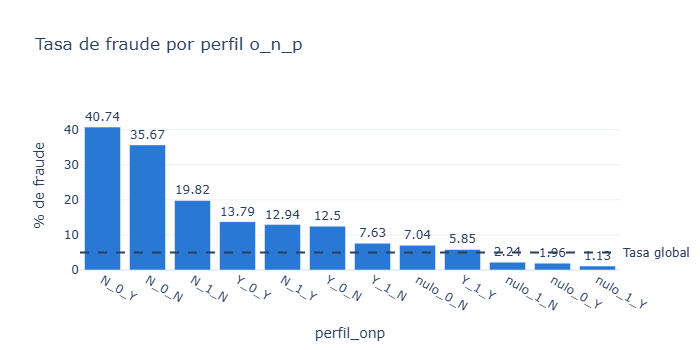

In [25]:
# Tasa de fraude por perfil, ordenada de mayor a menor riesgo
orden_perfiles = df.groupby('perfil_onp')['fraude'].mean().sort_values(ascending=False).index
graficar_tasa_fraude(
    df['fraude'],
    df['perfil_onp'].astype(pd.CategoricalDtype(orden_perfiles, ordered=True)),
    'Tasa de fraude por perfil o_n_p',
).show()

**💡 Hallazgos**

- **El riesgo se acumula**: el perfil `N_0_N` (`o = N`, `n = 0`, `p = N`) tiene **35,7% de fraude** sobre 4.626 transacciones, 7 veces la tasa global. En el otro extremo, `nulo_1_Y` concentra el 41% de las transacciones con solo 1,1%.
- `o` es la que más pesa: con `o` nulo, ningún perfil supera el 7%.
- `N_0_Y`, `Y_0_Y` y `Y_0_N` tienen menos de 30 transacciones cada uno, así que sus tasas son inestables.

## **🏆 Ranking univariado**

Para comparar todas las variables con la misma vara, cada una se convierte en la **tasa de fraude de su tramo** (deciles para las continuas, categorías para el resto, y el nulo como tramo propio), calculada out-of-fold. El AUC de esa tasa mide cuánta señal tiene la variable por sí sola, incluidas relaciones no monótonas como la de `score`.

In [26]:
# AUC univariado out-of-fold de cada variable, original o nueva, más una variable aleatoria como piso de ruido
features_nuevas = [columna for columna in df.columns if columna not in columnas_originales + ['fecha', 'fraude']]


def tramos(serie):
    """Deciles para las numéricas continuas y valores tal cual para las discretas y categóricas; el nulo queda como tramo propio."""
    if pd.api.types.is_numeric_dtype(serie) and serie.nunique() > MAXIMO_VALORES_DISCRETOS:
        serie = pd.qcut(serie, NUMERO_TRAMOS, duplicates='drop')
    return serie.astype(str)


variables_ranking = {columna: df[columna] for columna in columnas_originales + features_nuevas}
variables_ranking['aleatoria'] = pd.Series(np.random.default_rng(SEMILLA).uniform(size=len(df)), index=df.index)

ranking = pd.DataFrame([
    {
        'variable': nombre,
        'origen': 'Aleatoria' if nombre == 'aleatoria' else 'Nueva' if nombre in features_nuevas else 'Original',
        'auc': roc_auc_score(df['fraude'], tasa_fraude_oof(tramos(serie), df['fraude'], folds)),
    }
    for nombre, serie in variables_ranking.items()
]).sort_values('auc', ascending=False)
ranking.round(3)

,variable,origen,auc
34,perfil_onp,Nueva,0.799
16,score,Original,0.785
13,o,Original,0.754
5,f,Original,0.681
10,l,Original,0.669
11,m,Original,0.651
8,j,Original,0.645
30,ratio_f_l,Nueva,0.640
20,j_tasa_fraude,Nueva,0.639
31,ratio_m_l,Nueva,0.624


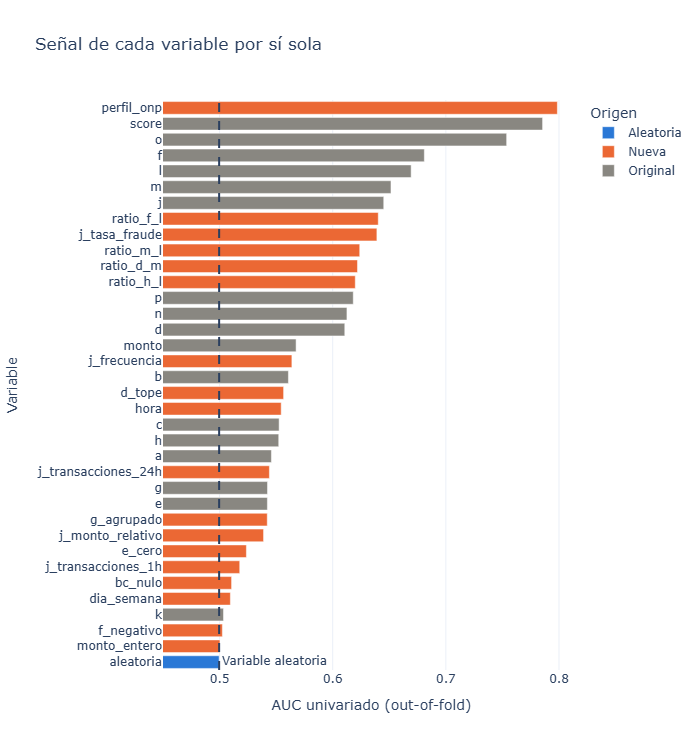

In [27]:
# Ranking visual con todas las variables juntas; lo que queda cerca o por debajo de la aleatoria no tiene señal propia
fig = px.bar(
    ranking.sort_values('auc'),
    x='auc',
    y='variable',
    color='origen',
    orientation='h',
    color_discrete_map=COLORES_ORIGEN,
    labels={'auc': 'AUC univariado (out-of-fold)', 'variable': 'Variable', 'origen': 'Origen'},
    title='Señal de cada variable por sí sola',
)
fig.update_xaxes(range=[0.45, ranking['auc'].max() + 0.02])
# Sin esto plotly agrupa las barras por color (una traza por origen) en lugar de ordenarlas por AUC
fig.update_yaxes(categoryorder='total ascending')
fig.add_vline(
    x=ranking.loc[ranking['variable'] == 'aleatoria', 'auc'].item(),
    line_dash='dash',
    annotation_text='Variable aleatoria',
    annotation_position='bottom right',
)
fig.update_layout(height=750)
fig.show()

**💡 Hallazgos**

- **`perfil_onp` es la variable con más señal individual (AUC 0,799)**, por encima de `score` (0,785) y de `o` (0,754). Es la única feature nueva que supera a todas las originales.
- `j_tasa_fraude` (0,639) tiene la misma señal que `j` (0,645): es la misma información en otro formato. Su valor está en cómo la usa el modelo (un número suavizado en lugar de 8.324 categorías para memorizar), y eso solo se puede medir entrenándolo.
- `hora` (0,554) queda en la mitad de la tabla: su señal es fuerte pero se concentra en las horas de poco volumen.
- **Sin señal**: la variable aleatoria marca el piso de ruido (0,500). `monto_entero` (0,500), `f_negativo` (0,502) y la original `k` (0,503) quedan pegadas a ella, lo que confirma la sospecha de la exploración de que `k` es ruido. `dia_semana` (0,510), `bc_nulo` (0,511) y `j_transacciones_1h` (0,518) apenas se separan del piso. En los flags poco frecuentes el AUC bajo también se explica porque tocan muy pocas transacciones: `f_negativo` duplica la tasa, pero en menos del 1% de los casos.
- El AUC univariado no mide interacciones ni aporte incremental: una variable con poca señal individual puede sumar dentro del modelo, y una con mucha puede ser redundante.

## **🔗 Redundancia**

In [28]:
# Para cada feature nueva numérica, la variable original con la que más se correlaciona (Spearman, en valor absoluto)
numericas_originales = df[columnas_originales].select_dtypes(include='number').columns
numericas_nuevas = df[features_nuevas].select_dtypes(include='number').columns
correlaciones = df[[*numericas_originales, *numericas_nuevas]].corr(method='spearman').loc[numericas_nuevas, numericas_originales]

pd.DataFrame({
    'variable original más cercana': correlaciones.abs().idxmax(axis=1),
    'correlación': correlaciones.abs().max(axis=1).round(3),
}).sort_values('correlación', ascending=False)

,variable original más cercana,correlación
ratio_f_l,f,0.912
e_cero,e,0.896
ratio_h_l,h,0.788
d_tope,d,0.766
ratio_m_l,m,0.718
j_monto_relativo,monto,0.681
ratio_d_m,m,0.515
j_transacciones_24h,h,0.161
f_negativo,f,0.160
j_frecuencia,h,0.158


**💡 Hallazgos**

- **Muy redundantes** (correlación > 0,75 con una original): `ratio_f_l` (0,91 con `f`), `e_cero` (0,90 con `e`), `ratio_h_l` (0,79 con `h`) y `d_tope` (0,77 con `d`). Para un modelo de árboles, casi no agregan información nueva.
- **Información nueva** (correlación < 0,2): `hora`, `j_tasa_fraude`, `j_frecuencia`, la actividad reciente de la categoría y los flags `f_negativo`, `bc_nulo` y `monto_entero`. Entre ellas, la actividad en 24 horas es redundante con `j_frecuencia` (0,89).
- `perfil_onp` y `g_agrupado` son categóricas y no están en la tabla. `perfil_onp` combina por construcción `o`, `n` y `p`, y su aporte es la interacción entre ellas.
- **Candidatas más prometedoras** para medir contra el baseline: `perfil_onp` (la más fuerte y no se reduce a una sola original), `hora` (señal clara e independiente), `j_tasa_fraude` y `j_frecuencia` (una alternativa a la `j` cruda que evita la memorización) y `g_agrupado` (por estabilidad).